<a href="https://colab.research.google.com/github/AnastasiaKovalenko232/iad-practices/blob/main/practice-4/4_2_NonLinear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

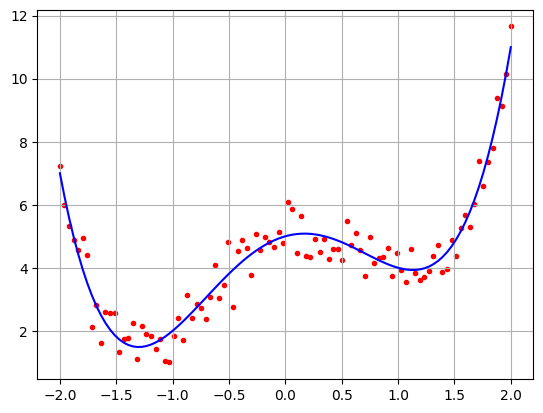

In [3]:
# generation of synthetic dataset

N = 100
x = np.linspace(-2, 2, N)
y = x ** 2 - 3
noise = np.random.normal(0, .5, N)

# original function
y0 = x**4 - 3* x**2 +x + 5

# "real data"
y = y0 + noise

plt.grid()
plt.scatter(x, y, marker = '.', color = 'r')
plt.plot(x, y0, color='b')

In [4]:
# Reshape for sklearn
x = x.reshape(-1, 1)

In [5]:
# Polynomial regression (degree=4, since the true function is quartic)
degree = 4
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(x, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=4)),
                ('linearregression', LinearRegression())])

In [6]:
x_fit = np.linspace(-2, 2, 200).reshape(-1, 1)
y_fit = model.predict(x_fit)

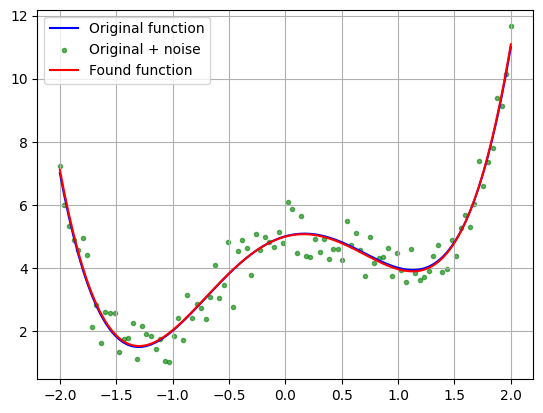

In [7]:
plt.grid()
plt.plot(x, y0, "b", label="Original function")
plt.scatter(x, y, color="g", marker =".", label="Original + noise", alpha=0.6)
plt.plot(x_fit, y_fit, "r", label="Found function")
plt.legend()

In [8]:
# accessing arguments found
linreg = model.named_steps["linearregression"]

In [9]:
# coefficients
linreg.coef_

array([ 0.        ,  0.95697512, -3.01146048,  0.00989795,  1.00955644])

In [10]:
# shift
linreg.intercept_

np.float64(4.989911508100215)

In [11]:
all = np.hstack(([linreg.intercept_], linreg.coef_[1:]))
all
#           5     +       x          + x^2    +    x^3     +    x^4

array([ 4.98991151,  0.95697512, -3.01146048,  0.00989795,  1.00955644])

Коефіцієнти полінома (від молодшого до старшого ступеня): [ 0.          0.98763752 -3.25212097 -0.01601196  1.04432923]
Вільний член (Intercept): 5.135469811736925


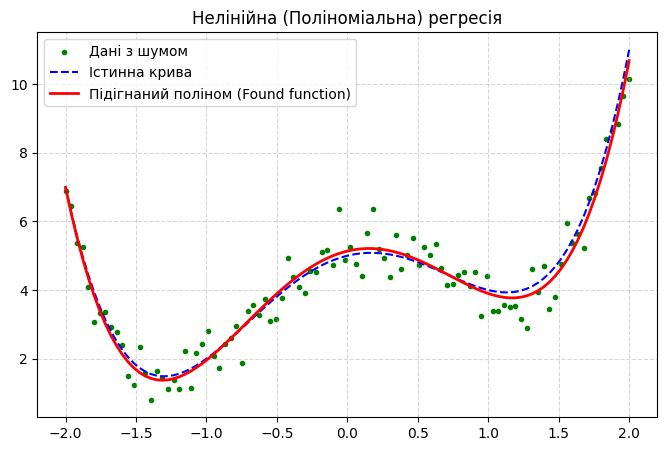

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# 1. Генерація складніших нелінійних даних (поліном 4-го ступеня)
N = 100
x = np.linspace(-2, 2, N)
noise = np.random.normal(0, 0.5, N)

# Оригінальна функція: y = x^4 - 3*x^2 + x + 5
y0 = x**4 - 3*x**2 + x + 5
y = y0 + noise

# Перетворюємо x на 2D матрицю
X = x.reshape(-1, 1)

# 2. Створення Pipeline: спочатку підносимо до ступеня (deg=4), потім будуємо регресію
degree = 4
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X, y)

# 3. Прогнозування для побудови плавної лінії
y_pred = model.predict(X)

# 4. Виведення знайдених коефіцієнтів
linreg = model.named_steps["linearregression"]
print("Коефіцієнти полінома (від молодшого до старшого ступеня):", linreg.coef_)
print("Вільний член (Intercept):", linreg.intercept_)

# 5. Візуалізація
plt.figure(figsize=(8, 5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.scatter(x, y, marker='.', color='g', label='Дані з шумом')
plt.plot(x, y0, color='blue', linestyle='--', label='Істинна крива')
plt.plot(x, y_pred, color='red', linewidth=2, label='Підігнаний поліном (Found function)')
plt.title('Нелінійна (Поліноміальна) регресія')
plt.legend()
plt.show()